In [63]:
%pip install seaborn

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
df = pd.read_csv("archive.zip")

In [66]:
print(df)

                      name online_order book_table   rate  votes  \
0                    Jalsa          Yes        Yes  4.1/5    775   
1           Spice Elephant          Yes         No  4.1/5    787   
2          San Churro Cafe          Yes         No  3.8/5    918   
3    Addhuri Udupi Bhojana           No         No  3.7/5     88   
4            Grand Village           No         No  3.8/5    166   
..                     ...          ...        ...    ...    ...   
143       Melting Melodies           No         No  3.3/5      0   
144        New Indraprasta           No         No  3.3/5      0   
145           Anna Kuteera          Yes         No  4.0/5    771   
146                 Darbar           No         No  3.0/5     98   
147          Vijayalakshmi          Yes         No  3.9/5     47   

     approx_cost(for two people) listed_in(type)  
0                            800          Buffet  
1                            800          Buffet  
2                            8

In [67]:
import zipfile

In [68]:
with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("zomato_data")

In [69]:
df = pd.read_csv("zomato_data/Zomato-data-.csv")

In [70]:
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


In [71]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [72]:
df.shape

(148, 7)

In [73]:
df.describe()

,votes,approx_cost(for two people)
count,148.000000,148.000000
mean,264.810811,418.243243
std,653.676951,223.085098
min,0.000000,100.000000
25%,6.750000,200.000000
50%,43.500000,400.000000
75%,221.750000,600.000000
max,4884.000000,950.000000


In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   name                         148 non-null    str  
 1   online_order                 148 non-null    str  
 2   book_table                   148 non-null    str  
 3   rate                         148 non-null    str  
 4   votes                        148 non-null    int64
 5   approx_cost(for two people)  148 non-null    int64
 6   listed_in(type)              148 non-null    str  
dtypes: int64(2), str(5)
memory usage: 5.3 KB


In [75]:
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [76]:
df['rate'] = df['rate'].str.replace('/5', '', regex=False)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

In [77]:
df['rate'].head()

0    4.1
1    4.1
2    3.8
3    3.7
4    3.8
Name: rate, dtype: float64

In [78]:
df['rate'].mean()

np.float64(3.6331081081081082)

In [79]:
df['approx_cost(for two people)'].mean()

np.float64(418.2432432432432)

In [80]:
df['rate'].max()

np.float64(4.6)

In [81]:
df['votes'].sum()

np.int64(39192)

In [82]:
df.sort_values('rate', ascending=False).head(10)

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
44,Onesta,Yes,Yes,4.6,2556,600,other
7,Onesta,Yes,Yes,4.6,2556,600,Cafes
38,Empire Restaurant,Yes,No,4.4,4884,750,other
86,Meghana Foods,Yes,No,4.4,4401,600,Dining
52,Corner House Ice Cream,No,No,4.3,345,400,Dining
37,Szechuan Dragon,Yes,No,4.2,1647,600,Dining
60,Peppy Peppers,No,No,4.2,244,800,other
81,Frozen Bottle,Yes,No,4.2,146,400,Dining
12,The Coffee Shack,Yes,Yes,4.2,164,500,Cafes
11,Cafe Shuffle,Yes,Yes,4.2,150,600,Cafes


In [83]:
df.sort_values('votes', ascending=False).head(10)

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
38,Empire Restaurant,Yes,No,4.4,4884,750,other
86,Meghana Foods,Yes,No,4.4,4401,600,Dining
7,Onesta,Yes,Yes,4.6,2556,600,Cafes
44,Onesta,Yes,Yes,4.6,2556,600,other
65,Kabab Magic,Yes,No,4.1,1720,400,Dining
37,Szechuan Dragon,Yes,No,4.2,1647,600,Dining
54,Roving Feast,No,No,4.0,1047,450,Dining
14,San Churro Cafe,Yes,No,3.8,918,800,Cafes
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
67,Gustoes Beer House,No,No,4.1,868,700,Dining


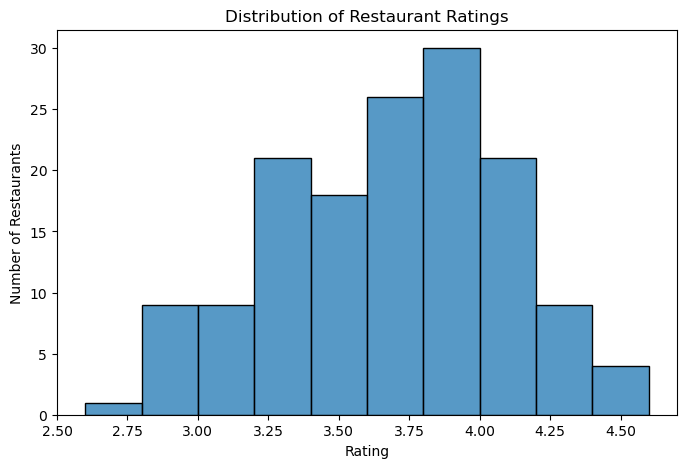

In [84]:
plt.figure(figsize=(8,5))

sns.histplot(df['rate'].dropna(), bins=10)

plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Restaurants')

plt.show()

In [85]:
df['approx_cost(for two people)'].mean()

np.float64(418.2432432432432)

In [86]:
df['approx_cost(for two people)'].min()

np.int64(100)

In [87]:
df['approx_cost(for two people)'].max

np.int64(950)

In [88]:
df['approx_cost(for two people)'].value_counts().head(10)

approx_cost(for two people)
300    23
200    16
150    16
400    15
500    14
600    13
800    12
450     6
100     6
250     6
Name: count, dtype: int64

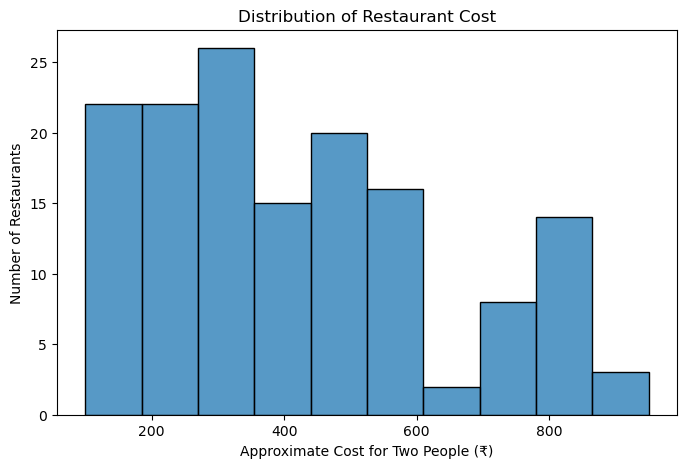

In [89]:
plt.figure(figsize=(8,5))

sns.histplot(df['approx_cost(for two people)'], bins=10)

plt.title('Distribution of Restaurant Cost')
plt.xlabel('Approximate Cost for Two People (₹)')
plt.ylabel('Number of Restaurants')

plt.show()

In [90]:
df['online_order'].value_counts()

online_order
No     90
Yes    58
Name: count, dtype: int64

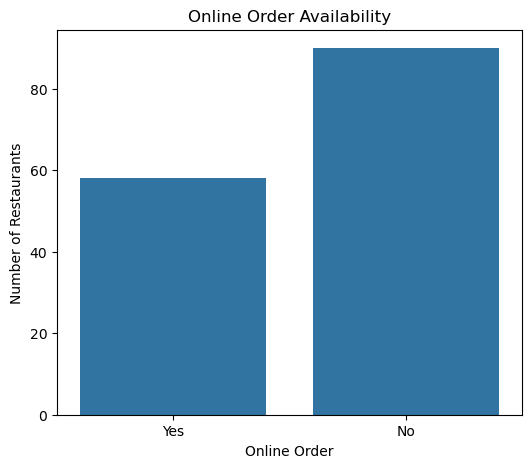

In [91]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='online_order')

plt.title('Online Order Availability')
plt.xlabel('Online Order')
plt.ylabel('Number of Restaurants')

plt.show()

In [92]:
df['book_table'].value_counts()

book_table
No     140
Yes      8
Name: count, dtype: int64

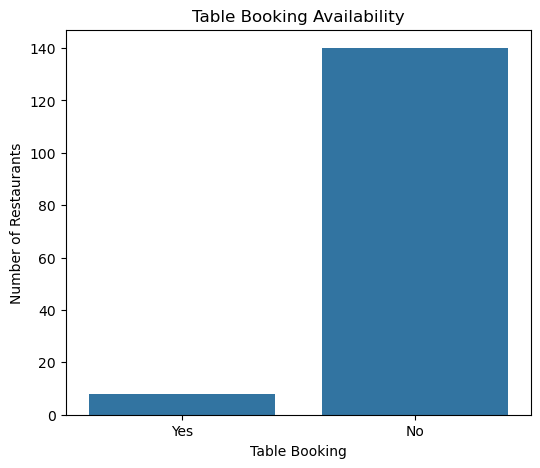

In [93]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='book_table')

plt.title('Table Booking Availability')
plt.xlabel('Table Booking')
plt.ylabel('Number of Restaurants')

plt.show()

In [94]:
df['listed_in(type)'].value_counts()

listed_in(type)
Dining    110
Cafes      23
other       8
Buffet      7
Name: count, dtype: int64

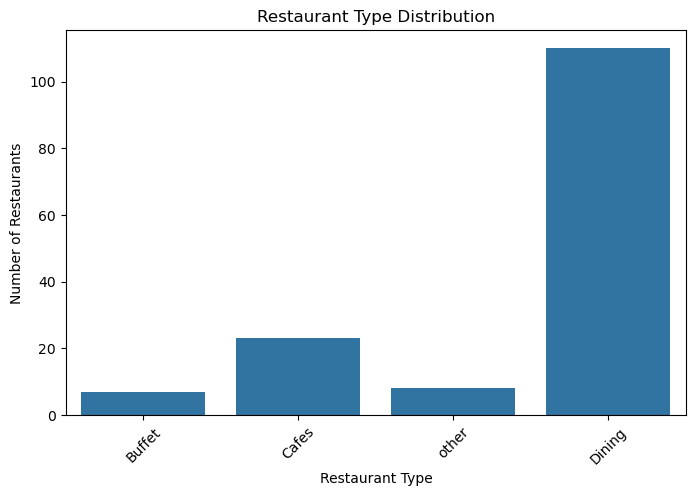

In [95]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='listed_in(type)'
)

plt.title('Restaurant Type Distribution')
plt.xlabel('Restaurant Type')
plt.ylabel('Number of Restaurants')

plt.xticks(rotation=45)

plt.show()

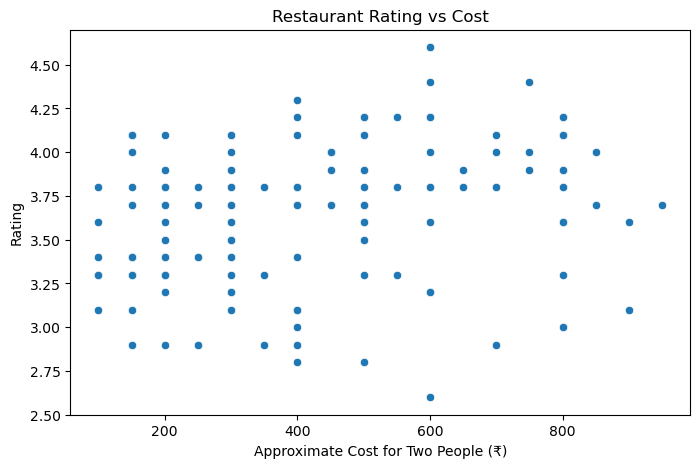

In [96]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='approx_cost(for two people)',
    y='rate'
)

plt.title('Restaurant Rating vs Cost')
plt.xlabel('Approximate Cost for Two People (₹)')
plt.ylabel('Rating')

plt.show()

In [97]:
df['value_score'] = (
    df['rate'] / df['approx_cost(for two people)']
) * 1000

In [98]:
df.sort_values(
    'value_score',
    ascending=False
)[['name', 'rate', 'approx_cost(for two people)', 'value_score']].head(10)

,name,rate,approx_cost(for two people),value_score
84,Chill Out,3.8,100,38.000000
66,Namma Brahmin's Idli,3.6,100,36.000000
131,Foodlieious Multi Cuisine,3.4,100,34.000000
143,Melting Melodies,3.3,100,33.000000
127,Ruchi Maayaka,3.3,100,33.000000
122,Coffee Bytes,3.1,100,31.000000
51,Shree Cool Point,4.1,150,27.333333
76,Sri Guru Kottureshwara Davangere Benne Dosa,4.1,150,27.333333
72,Spicy Tandoor,4.1,150,27.333333
39,Maruthi Davangere Benne Dosa,4.0,150,26.666667


In [99]:
df.sort_values(
    'votes',
    ascending=False
)[['name', 'rate', 'votes']].head(10)

,name,rate,votes
38,Empire Restaurant,4.4,4884
86,Meghana Foods,4.4,4401
7,Onesta,4.6,2556
44,Onesta,4.6,2556
65,Kabab Magic,4.1,1720
37,Szechuan Dragon,4.2,1647
54,Roving Feast,4.0,1047
14,San Churro Cafe,3.8,918
2,San Churro Cafe,3.8,918
67,Gustoes Beer House,4.1,868


In [100]:
df['value_score'] = (
    df['rate'] / df['approx_cost(for two people)']
) * 1000

value_restaurants = df.sort_values(
    'value_score',
    ascending=False
)[['name', 'rate', 'approx_cost(for two people)', 'value_score']]

value_restaurants.head(10)

,name,rate,approx_cost(for two people),value_score
84,Chill Out,3.8,100,38.000000
66,Namma Brahmin's Idli,3.6,100,36.000000
131,Foodlieious Multi Cuisine,3.4,100,34.000000
143,Melting Melodies,3.3,100,33.000000
127,Ruchi Maayaka,3.3,100,33.000000
122,Coffee Bytes,3.1,100,31.000000
51,Shree Cool Point,4.1,150,27.333333
76,Sri Guru Kottureshwara Davangere Benne Dosa,4.1,150,27.333333
72,Spicy Tandoor,4.1,150,27.333333
39,Maruthi Davangere Benne Dosa,4.0,150,26.666667


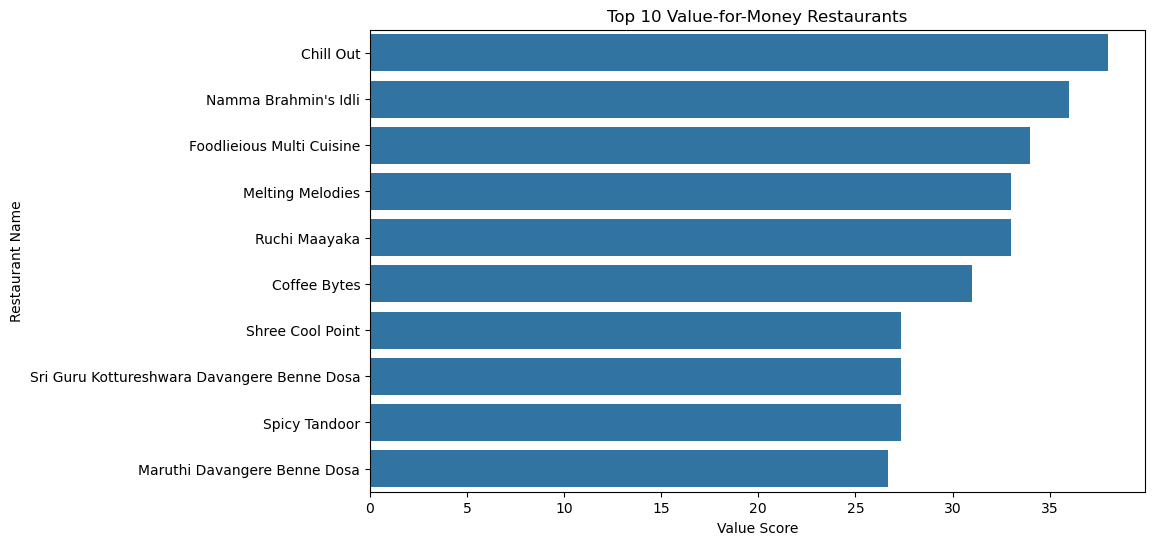

In [101]:
top_value = value_restaurants.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_value,
    x='value_score',
    y='name'
)

plt.title('Top 10 Value-for-Money Restaurants')
plt.xlabel('Value Score')
plt.ylabel('Restaurant Name')

plt.show()

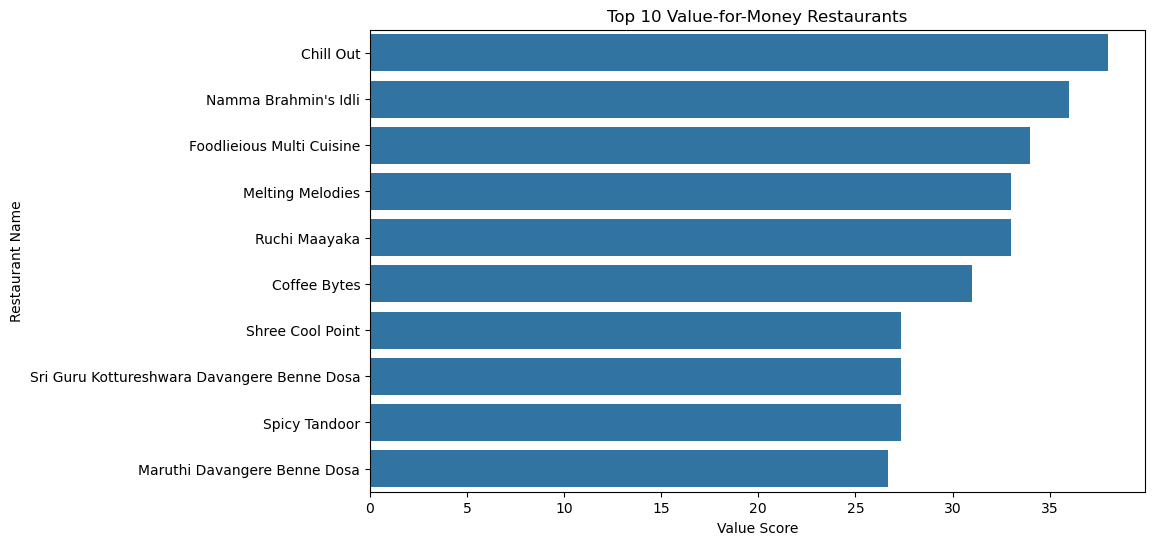

In [102]:
top_value = value_restaurants.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_value,
    x='value_score',
    y='name'
)

plt.title('Top 10 Value-for-Money Restaurants')
plt.xlabel('Value Score')
plt.ylabel('Restaurant Name')

plt.show()

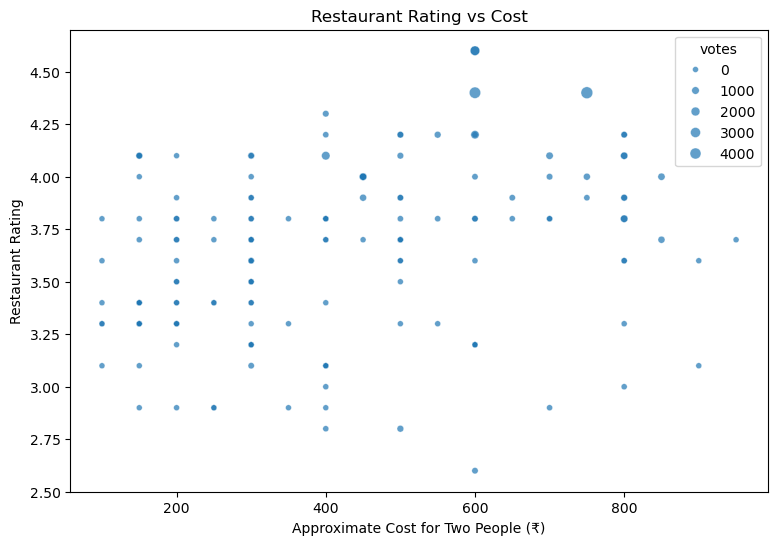

In [103]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='approx_cost(for two people)',
    y='rate',
    size='votes',
    alpha=0.7
)

plt.title('Restaurant Rating vs Cost')
plt.xlabel('Approximate Cost for Two People (₹)')
plt.ylabel('Restaurant Rating')
plt.show()

In [104]:
online_order_count = df['online_order'].value_counts()

print(online_order_count)

online_order
No     90
Yes    58
Name: count, dtype: int64


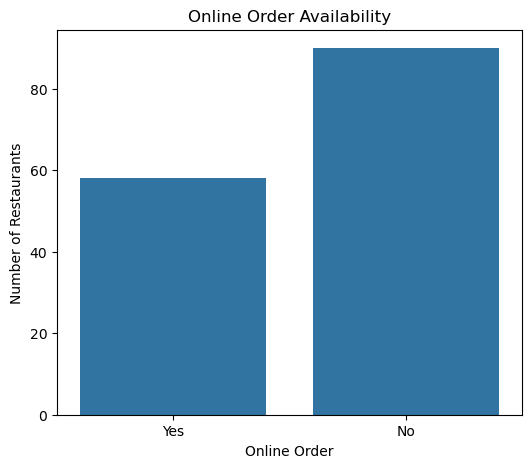

In [105]:
plt.figure(figsize=(6, 5))

sns.countplot(
    data=df,
    x='online_order'
)

plt.title('Online Order Availability')
plt.xlabel('Online Order')
plt.ylabel('Number of Restaurants')

plt.show()

In [106]:
online_rating = df.groupby('online_order')['rate'].mean()

print(online_rating)

online_order
No     3.487778
Yes    3.858621
Name: rate, dtype: float64


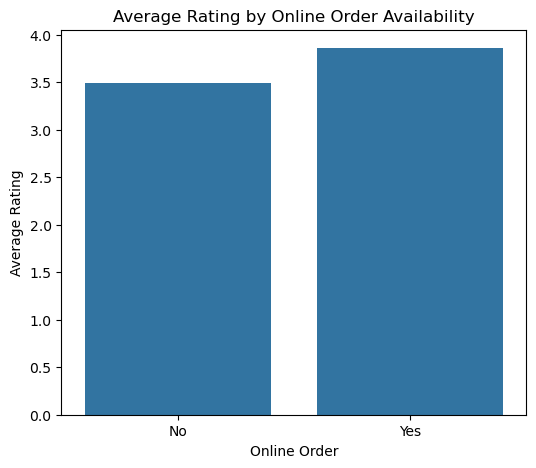

In [107]:
plt.figure(figsize=(6, 5))

sns.barplot(
    x=online_rating.index,
    y=online_rating.values
)

plt.title('Average Rating by Online Order Availability')
plt.xlabel('Online Order')
plt.ylabel('Average Rating')

plt.show()

In [108]:
table_booking_count = df['book_table'].value_counts()

print(table_booking_count)

book_table
No     140
Yes      8
Name: count, dtype: int64


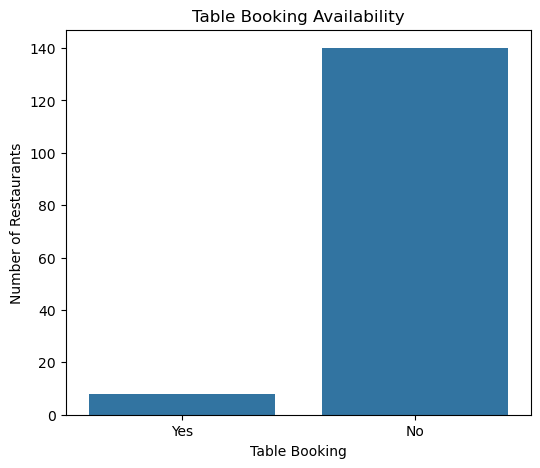

In [109]:
plt.figure(figsize=(6, 5))

sns.countplot(
    data=df,
    x='book_table'
)

plt.title('Table Booking Availability')
plt.xlabel('Table Booking')
plt.ylabel('Number of Restaurants')

plt.show()

In [110]:
booking_rating = df.groupby('book_table')['rate'].mean()

print(booking_rating)

book_table
No     3.601429
Yes    4.187500
Name: rate, dtype: float64


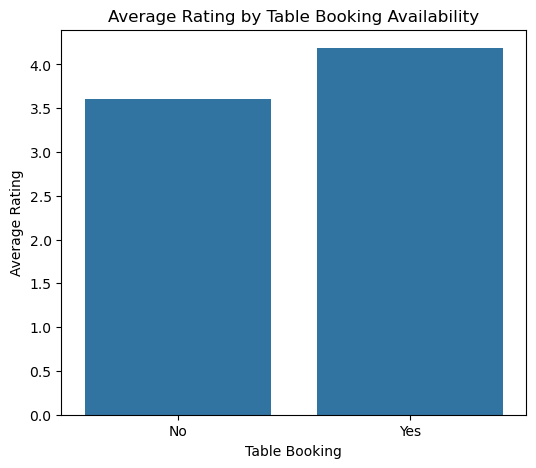

In [111]:
plt.figure(figsize=(6, 5))

sns.barplot(
    x=booking_rating.index,
    y=booking_rating.values
)

plt.title('Average Rating by Table Booking Availability')
plt.xlabel('Table Booking')
plt.ylabel('Average Rating')

plt.show()

In [112]:
restaurant_type_count = df['listed_in(type)'].value_counts()

print(restaurant_type_count)

listed_in(type)
Dining    110
Cafes      23
other       8
Buffet      7
Name: count, dtype: int64


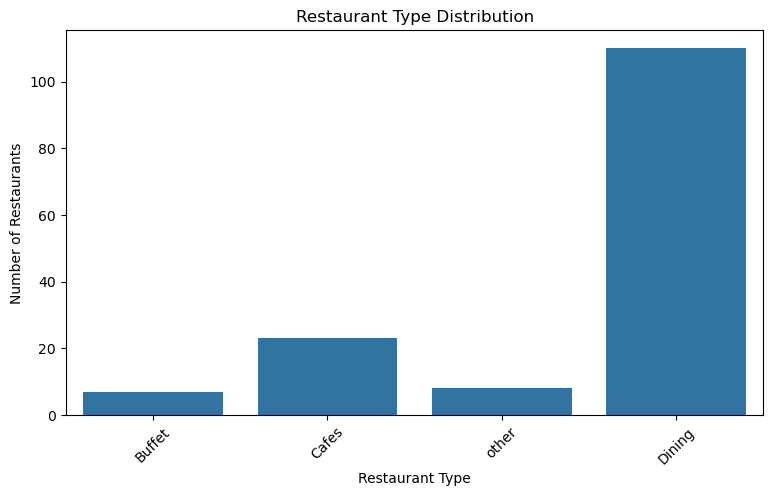

In [113]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x='listed_in(type)'
)

plt.title('Restaurant Type Distribution')
plt.xlabel('Restaurant Type')
plt.ylabel('Number of Restaurants')

plt.xticks(rotation=45)

plt.show()

In [114]:
type_rating = df.groupby('listed_in(type)')['rate'].mean().sort_values(
    ascending=False
)

print(type_rating)

listed_in(type)
other     3.912500
Buffet    3.842857
Cafes     3.765217
Dining    3.571818
Name: rate, dtype: float64


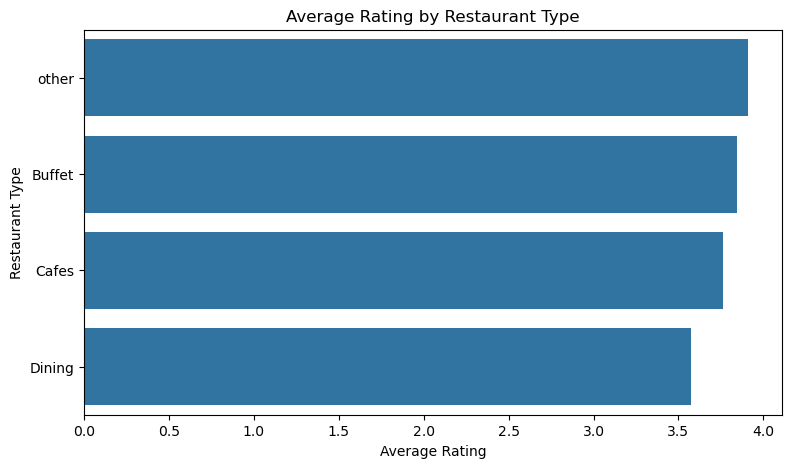

In [115]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=type_rating.values,
    y=type_rating.index
)

plt.title('Average Rating by Restaurant Type')
plt.xlabel('Average Rating')
plt.ylabel('Restaurant Type')

plt.show()

In [116]:
top_rated = df.sort_values(
    'rate',
    ascending=False
)[['name', 'rate', 'votes', 'approx_cost(for two people)']]

top_rated.head(10)

,name,rate,votes,approx_cost(for two people)
44,Onesta,4.6,2556,600
7,Onesta,4.6,2556,600
38,Empire Restaurant,4.4,4884,750
86,Meghana Foods,4.4,4401,600
52,Corner House Ice Cream,4.3,345,400
37,Szechuan Dragon,4.2,1647,600
60,Peppy Peppers,4.2,244,800
81,Frozen Bottle,4.2,146,400
12,The Coffee Shack,4.2,164,500
11,Cafe Shuffle,4.2,150,600


In [117]:
top_rated_votes = df.sort_values(
    ['rate', 'votes'],
    ascending=[False, False]
)[['name', 'rate', 'votes', 'approx_cost(for two people)']]

top_rated_votes.head(10)

,name,rate,votes,approx_cost(for two people)
7,Onesta,4.6,2556,600
44,Onesta,4.6,2556,600
38,Empire Restaurant,4.4,4884,750
86,Meghana Foods,4.4,4401,600
52,Corner House Ice Cream,4.3,345,400
37,Szechuan Dragon,4.2,1647,600
9,Smacznego,4.2,504,550
34,Faasos,4.2,415,500
57,Wamama,4.2,354,800
60,Peppy Peppers,4.2,244,800


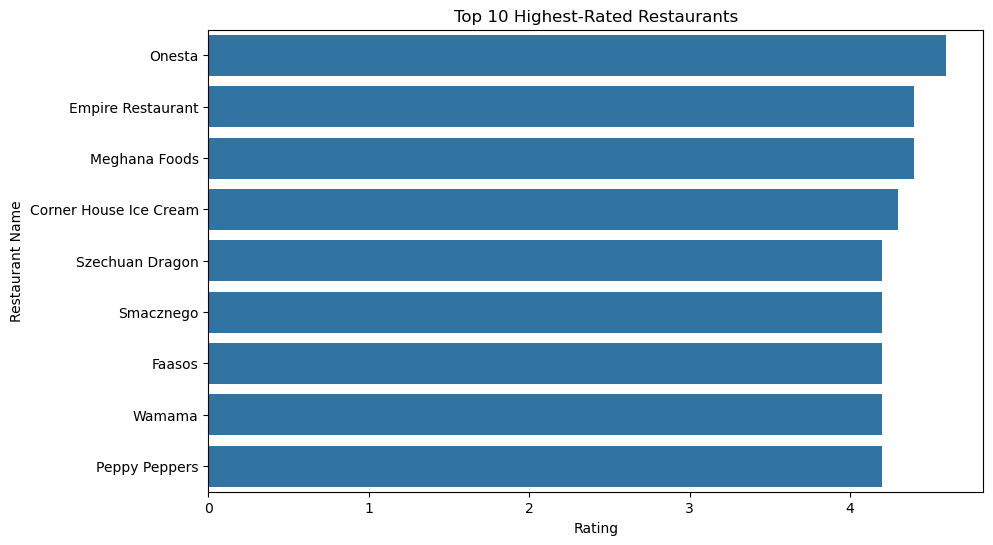

In [118]:
top_10_rated = top_rated_votes.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_rated,
    x='rate',
    y='name'
)

plt.title('Top 10 Highest-Rated Restaurants')
plt.xlabel('Rating')
plt.ylabel('Restaurant Name')

plt.show()

In [119]:
!pip install streamlit

<class 'OSError'>: Not available